___We recommend working with this notebook on Google Colab.___
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ridatadiscoverycenter/riddc-jbook/blob/main/riddc/notebooks/fox-kemper/osom_regrid.ipynb)

# Regridding OSOM Data with Scipy

Author of this document: Anna Murphy <a href="https://github.com/anna-murphy"><img width="75" height="25" style="vertical-align:middle;" src="https://img.shields.io/badge/github-%23121011.svg?style=for-the-badge&logo=github&logoColor=white"></a>

The OSOM Regridder utilizes `scipy`'s `griddata` function to interpole model data across a lon/lat grid.

In [ ]:
# Dependencies needed for regridding

import netCDF4 as nc

import numpy as np

import scipy
import scipy.interpolate as interpolate
from scipy.interpolate import griddata

import cartopy
import cartopy.crs as ccrs
import cartopy.img_transform as transform

import matplotlib.pyplot as plt


# Additional libraries for image display.

from PIL import Image
from IPython.display import display
from matplotlib.pyplot import imshow

The OSOM datasets are stored on Oscar and can be loaded from pre-set paths. 

In [ ]:
grid_path="/oscar/data/epscor/OSOM/input/ROMS_forcing_files/grid/osom_grid4_mindep_smlp_mod10.nc"
data_path="/oscar/data/epscor/OSOM/output/OSOM_v2/2022/"
data_filename="ocean_his_6210.nc"

The bounds of the output map are pre-set and defined here:

In [ ]:
LON_W = -72.7
LON_E = -69.96
LAT_N = 41.9
LAT_S = 40.5

Load grid and dataset NetCDF files.

In [ ]:
# Import grid and get grid information
grid = nc.Dataset(grid_path)
lon = grid.variables['lon_rho'][:]
lat = grid.variables['lat_rho'][:]
mask = grid.variables['mask_rho'][:]
bathy = grid.variables['h'][:]

# Import data
ds = nc.Dataset(data_path + data_filename)
time = ds.variables['ocean_time'][:]
# Variables: temp, salt, zeta, ubar_eastward, ubar_westward
data_varname="temp"
# Surface layers: [:,-1,:,:];
# Bottom layers: [:,0,:,:]
data = ds.variables[data_varname][:,-1,:,:]

To perform the regridding, the dataset needs to be transformed into three one dimensional arrays of longitude (x), latutitude (y), and data (z). This creates a 3D scatter plot that SciPy can interpolate over.

In [ ]:
# Flatten Data into a series of ungridded points
x = lon.flatten()
y = lat.flatten()
z = data[2].flatten()
# To view regridded bathymetry data, assign flatted bathymetry data to the z variable.
#z = bathy.flatten()

/oscar/home/amurph40/notebooks/riddc/osom-visualization/.env/lib64/python3.9/site-packages/matplotlib/cbook.py:1762: UserWarning: Warning: converting a masked element to nan.
  return math.isfinite(val)


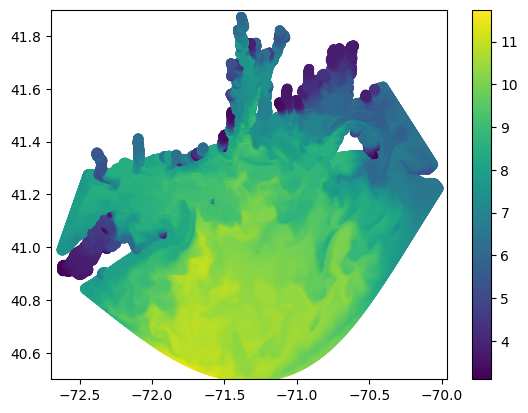

In [ ]:
# Plot the 3D scatter plot of the model data.
plt.scatter(x,y,c=z)
plt.axis([LON_W, LON_E, LAT_S, LAT_N])
plt.colorbar()
plt.show()

To actually convert the data into a new grid, we're going to use `scipy`'s `griddata` function. This is a function that interpolates any 3D mesh onto any other arbitrary 3D mesh. The previous flattening of the data allows `scipy` to interpret model data as a mesh, but we still have to create the output mesh and then populate it with data.

In [ ]:
# Output Grid Pixel Dimensions
ny, nx = 160 * 4, 260 * 4

# Generate the grid on which to interpolate data.
xi = np.linspace(LON_W, LON_E, nx)
yi = np.linspace(LAT_S, LAT_N, ny)
xi, yi = np.meshgrid(xi, yi)

# Interpolate using delaunay triangularization 
zi = griddata( (x,y), z, (xi,yi) )

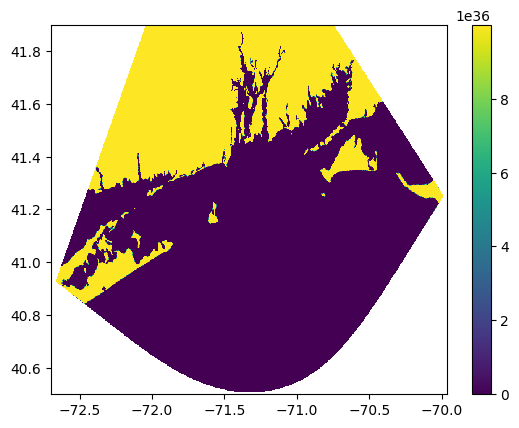

In [ ]:
# Plot the results of the regridding.
plt.figure()
plt.pcolormesh(xi,yi,zi)
#plt.scatter(x,y,c=z)
plt.colorbar()
plt.axis([LON_W, LON_E, LAT_S, LAT_N])
plt.show()

Now, we need to convert the array of data into an image that can be geolocated. This script quickly creates and saves an image based on the regrid output. 

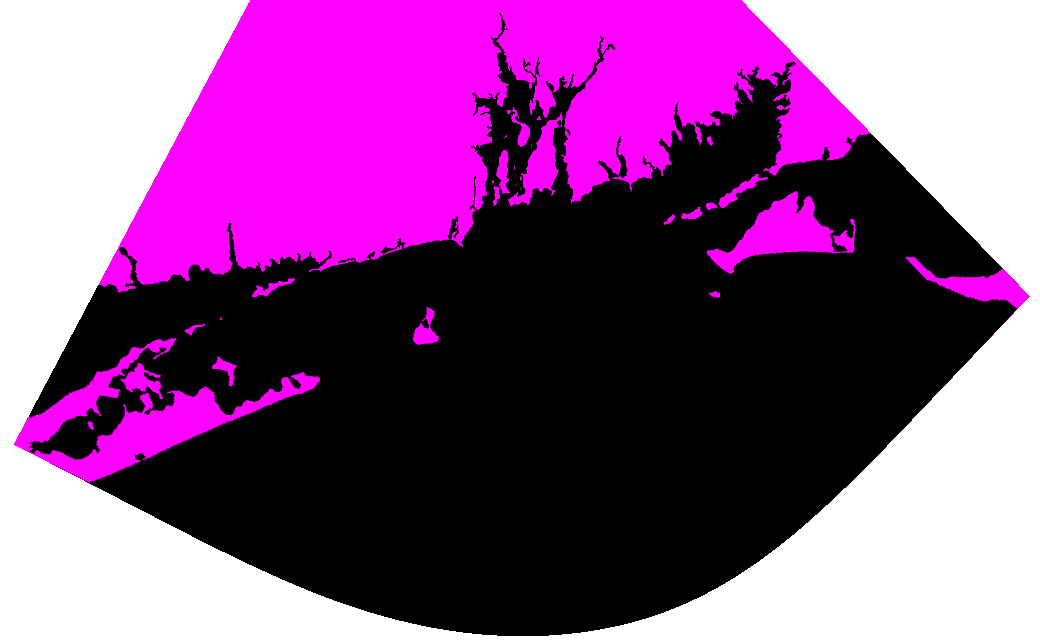

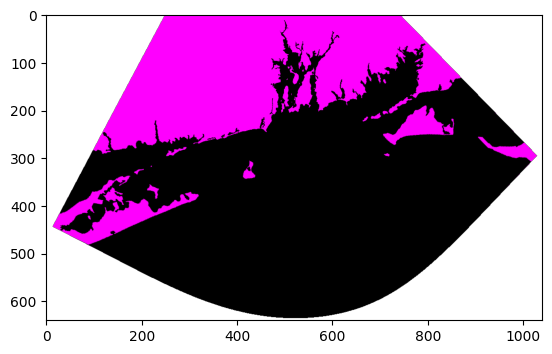

In [ ]:
values = np.unique(zi[~np.isnan(zi)])
output_min = np.min(values)
output_max = np.max(values)

def normalize(v, v_scale_min, v_scale_max, o_scale_min, o_scale_max):
    standard_normalization = (v - v_scale_min) / (v_scale_max - v_scale_min)
    return ((o_scale_max - o_scale_min) * standard_normalization) + o_scale_min

def create_image(dataset):
    shape = dataset.shape[::-1]
    # Create a base transparent image
    image = Image.new(mode="RGBA", size=shape, color = (0, 0, 0, 0))
    for x in range(shape[0]):
        for y in range(shape[1]):
            value = dataset[y][x]
            if not np.isnan(value):
                color_as_value = int(normalize(value, output_min, output_max, 0, 255))
                image.putpixel((x, shape[1] - 1 - y), (color_as_value, 0, color_as_value, 255))
    return image
    
im = create_image(zi)
display(im)
imshow(np.asarray(im))
im.save(f"{1600}x{2600}-databay.png")